# AI-Powered Resume Screening System

## Machine Learning Model Training Pipeline

This notebook performs feature engineering, vectorization, machine learning model training, prediction, and evaluation for automated resume classification.

| Stage | Description |
|---|---|
| Data Loading | Import resume dataset |
| NLP Cleaning | Normalize and preprocess resume text |
| Feature Engineering | Convert text into TF-IDF vectors |
| Data Splitting | Create training and testing datasets |
| Model Training | Train machine learning classifier |
| Prediction | Predict resume categories |
| Evaluation | Measure model performance |
| Model Export | Save trained model for deployment |

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
import warnings

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (8,4)

print("All libraries imported successfully")

All libraries imported successfully


# Dataset Loading

The resume dataset is loaded into the notebook environment for machine learning preprocessing and classification tasks.

In [2]:
df = pd.read_csv("../data/resume_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10, 2)


,resume,category
0,Python developer with machine learning experience,Data Scientist
1,Java backend developer with spring boot,Backend Developer
2,Frontend developer with html css javascript,Frontend Developer
3,Android developer with kotlin experience,Mobile Developer
4,Data analyst with sql and excel skills,Data Analyst


# Dataset Information

This section analyzes the structure and properties of the dataset before machine learning operations.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   resume    10 non-null     object
 1   category  10 non-null     object
dtypes: object(2)
memory usage: 288.0+ bytes


In [4]:
df.isnull().sum()

resume      0
category    0
dtype: int64

| Dataset Validation Step | Status |
|---|---|
| Dataset Loaded | Completed |
| Dataset Shape Verified | Completed |
| Column Inspection | Completed |
| Null Value Analysis | Completed |
| Dataset Ready for NLP | Verified |

# NLP Text Preprocessing

Resume text data is cleaned and normalized using Natural Language Processing techniques before feature engineering.

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Akshitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [7]:
df['clean_resume'] = df['resume'].apply(clean_text)

df[['resume', 'clean_resume']].head()

,resume,clean_resume
0,Python developer with machine learning experience,python developer machine learning experience
1,Java backend developer with spring boot,java backend developer spring boot
2,Frontend developer with html css javascript,frontend developer html css javascript
3,Android developer with kotlin experience,android developer kotlin experience
4,Data analyst with sql and excel skills,data analyst sql excel skills


In [8]:
print("ORIGINAL RESUME:\n")

print(df['resume'].iloc[0])

print("\n")

print("CLEANED RESUME:\n")

print(df['clean_resume'].iloc[0])

ORIGINAL RESUME:

Python developer with machine learning experience


CLEANED RESUME:

python developer machine learning experience


# TF-IDF Feature Engineering

TF-IDF converts resume text into numerical vectors so machine learning models can understand textual data.

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_resume']).toarray()

y = df['category']

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (10, 35)


# Dataset Splitting



In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8, 35)
Testing Data Shape: (2, 35)


# Logistic Regression Model Training

In [11]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


# Resume Category Prediction

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:5])

['Data Scientist' 'Data Scientist']


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.0


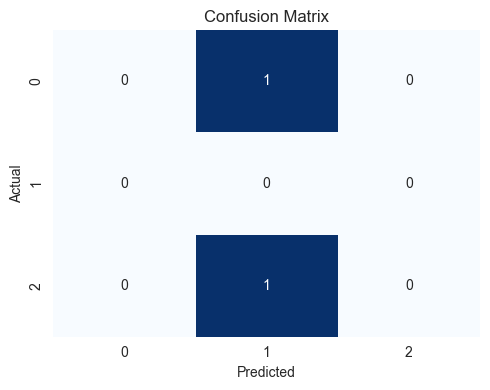

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

In [16]:
plt.figure(figsize=(4,3))

<Figure size 400x300 with 0 Axes>

<Figure size 400x300 with 0 Axes>

In [17]:
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

Backend Developer       0.00      0.00      0.00       1.0
   Data Scientist       0.00      0.00      0.00       0.0
Software Engineer       0.00      0.00      0.00       1.0

         accuracy                           0.00       2.0
        macro avg       0.00      0.00      0.00       2.0
     weighted avg       0.00      0.00      0.00       2.0

